# Employee Attrition Prediction — Model Training
### Phase 3: Stacking Ensemble (ANN + Random Forest + LightGBM) with Logistic Regression Meta-Learner

This notebook trains a **stacking ensemble**:

- **Base learners:** Artificial Neural Network (Keras), Random Forest, LightGBM
- **Meta-learner:** Logistic Regression, trained on out-of-fold predictions from the base learners

Preprocessing is **not** redefined here — it reuses `preprocess_data.py` (`DataPreprocessor`) exactly as-is,
so the cleaning/encoding/scaling logic lives in one place and stays identical between training and any
future retraining runs.

**Artifacts produced by this notebook** (saved to `../backend/models/`):
- `final_rf.pkl` — Random Forest, refit on full training data
- `final_lgbm.pkl` — LightGBM, refit on full training data
- `final_ann.h5` — ANN, refit on full training data
- `meta_learner.pkl` — Logistic Regression meta-learner
- (from `preprocess_data.py`) `artifacts/preprocessor.pkl`, `artifacts/target_encoder.pkl`, `artifacts/feature_names.pkl`


In [4]:
pip install lightGBM


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)


## 1. Imports

In [5]:
import os
import sys
import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

from lightgbm import LGBMClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import HeNormal, GlorotUniform
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")


## 2. Load & Preprocess Data (reusing `preprocess_data.py`)

`DataPreprocessor` already handles: loading the CSV, dropping constant/ID columns, dropping duplicates,
splitting features/target, identifying numeric vs categorical columns, building the
`ColumnTransformer` (median-impute + scale numeric, most-frequent-impute + one-hot categorical),
encoding the target, doing the stratified train/test split, and saving the fitted preprocessor +
target encoder + feature names to `artifacts/`.

We just call it — no logic is duplicated here.


In [6]:
# Make preprocess_data.py importable (it lives alongside this notebook in ml-training/)
sys.path.append(os.path.abspath("."))
from preprocess_data import DataPreprocessor

DATASET_PATH = "dataset.csv"  # place the CSV alongside this notebook, or update the path

processor = DataPreprocessor(DATASET_PATH)
X_train, X_test, y_train, y_test = processor.process()

# OneHotEncoder in the ColumnTransformer can return a sparse matrix depending on sklearn config —
# Keras needs dense arrays, and RF/LightGBM are happiest with dense too at this dataset size.
if hasattr(X_train, "toarray"):
    X_train = X_train.toarray()
if hasattr(X_test, "toarray"):
    X_test = X_test.toarray()

y_train = np.asarray(y_train)
y_test = np.asarray(y_test)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("Positive class rate — train:", y_train.mean().round(3), " test:", y_test.mean().round(3))



Loading Dataset...
Dataset Loaded Successfully
Shape : (1470, 35)

Cleaning Dataset...
Dataset Cleaned
New Shape : (1470, 31)

Numerical Features : 23
Categorical Features : 7

Saving Artifacts...
Artifacts Saved Successfully

Preprocessing Completed Successfully
----------------------------------------
Training Samples : (1176, 51)
Testing Samples  : (294, 51)
Processed Features : 51
----------------------------------------
X_train: (1176, 51)  X_test: (294, 51)
Positive class rate — train: 0.162  test: 0.16


## 3. Handle Class Imbalance

Attrition datasets are imbalanced (far more "No" than "Yes"). We compute:
- `class_weight` dict for the ANN and Random Forest
- `scale_pos_weight` for LightGBM (its native imbalance parameter)

All three are computed from the **training split only**, never the test split.


In [7]:
neg, pos = np.bincount(y_train)
total = neg + pos

class_weight_dict = {
    0: total / (2 * neg),
    1: total / (2 * pos),
}
scale_pos_weight = neg / pos

print("class_weight:", class_weight_dict)
print("scale_pos_weight (LightGBM):", round(scale_pos_weight, 3))


class_weight: {0: 0.5963488843813387, 1: 3.094736842105263}
scale_pos_weight (LightGBM): 5.189


## 4. Base Learner Definitions

### 4.1 ANN architecture

| Layer | Units | Activation | Initializer | Notes |
|---|---|---|---|---|
| Input | n_features | — | — | |
| Dense 1 | 64 | ReLU | He Normal | + BatchNorm + Dropout(0.3) |
| Dense 2 | 32 | ReLU | He Normal | + Dropout(0.2) |
| Dense 3 | 16 | ReLU | He Normal | |
| Output | 1 | Sigmoid | Glorot Uniform | binary probability |

Optimizer: Adam (lr=0.001) · Loss: binary cross-entropy · Regularization: Dropout + BatchNorm ·
Callbacks: EarlyStopping + ReduceLROnPlateau.


In [8]:
def build_ann(input_dim):
    model = Sequential([
        Dense(64, activation="relu", kernel_initializer=HeNormal(), input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation="relu", kernel_initializer=HeNormal()),
        Dropout(0.2),
        Dense(16, activation="relu", kernel_initializer=HeNormal()),
        Dense(1, activation="sigmoid", kernel_initializer=GlorotUniform()),
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
    )
    return model


def build_rf():
    return RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight=class_weight_dict,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


def build_lgbm():
    return LGBMClassifier(
        n_estimators=400,
        learning_rate=0.03,
        num_leaves=31,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
    )


## 5. Out-of-Fold (OOF) Stacking

To train the meta-learner without leaking information, each base learner produces predictions on
data it never saw during that fold's training — standard K-fold stacking:

1. Split `X_train` into `K` folds (stratified).
2. For each fold: train the base learner on the other `K-1` folds, predict probabilities on the held-out fold (→ OOF predictions) and on `X_test` (→ averaged later).
3. Stack the `K` test-fold predictions by averaging → one test prediction per base learner.
4. The meta-learner (Logistic Regression) trains on the OOF predictions (`Z_train`) against `y_train`.

Separately, we also refit each base learner on the **full** training set — those are the models saved
for production inference (Section 7), since at inference time there's no "held-out fold" concept.


In [10]:
N_SPLITS = 5

def get_oof_predictions(build_model_fn, X, y, X_test, is_keras=False, ann_epochs=100, ann_batch_size=32):
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    oof_preds = np.zeros(X.shape[0])
    test_fold_preds = np.zeros((N_SPLITS, X_test.shape[0]))



    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        if is_keras:
            model = build_model_fn(X.shape[1])
            callbacks = [
                EarlyStopping(patience=10, restore_best_weights=True, monitor="val_auc", mode="max"),
                ReduceLROnPlateau(factor=0.5, patience=5, monitor="val_loss"),
            ]
            model.fit(
                X_tr, y_tr,
                validation_data=(X_val, y_val),
                epochs=ann_epochs,
                batch_size=ann_batch_size,
                class_weight=class_weight_dict,
                callbacks=callbacks,
                verbose=0,
            )
            oof_preds[val_idx] = model.predict(X_val, verbose=0).ravel()
            test_fold_preds[fold] = model.predict(X_test, verbose=0).ravel()
        else:
            model = build_model_fn()
            model.fit(X_tr, y_tr)
            oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
            test_fold_preds[fold] = model.predict_proba(X_test)[:, 1]

        print(f"  [{build_model_fn.__name__}] fold {fold + 1}/{N_SPLITS} done")

    return oof_preds, test_fold_preds.mean(axis=0)


print("Generating OOF predictions — Random Forest")
oof_rf, test_rf = get_oof_predictions(build_rf, X_train, y_train, X_test)

print("Generating OOF predictions — LightGBM")
oof_lgbm, test_lgbm = get_oof_predictions(build_lgbm, X_train, y_train, X_test)

print("Generating OOF predictions — ANN")
oof_ann, test_ann = get_oof_predictions(build_ann, X_train, y_train, X_test, is_keras=True)


Generating OOF predictions — Random Forest
  [build_rf] fold 1/5 done
  [build_rf] fold 2/5 done
  [build_rf] fold 3/5 done
  [build_rf] fold 4/5 done
  [build_rf] fold 5/5 done
Generating OOF predictions — LightGBM


c:\Users\sabhi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\sabhi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  [build_lgbm] fold 1/5 done


c:\Users\sabhi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\sabhi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  [build_lgbm] fold 2/5 done


...

  [build_lgbm] fold 4/5 done


c:\Users\sabhi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\sabhi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  [build_lgbm] fold 5/5 done
Generating OOF predictions — ANN


c:\Users\sabhi\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  [build_ann] fold 1/5 done
  [build_ann] fold 2/5 done
  [build_ann] fold 3/5 done
  [build_ann] fold 4/5 done
  [build_ann] fold 5/5 done


## 6. Train the Meta-Learner (Logistic Regression)

In [11]:
Z_train = np.column_stack([oof_rf, oof_lgbm, oof_ann])
Z_test = np.column_stack([test_rf, test_lgbm, test_ann])

meta_learner = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
meta_learner.fit(Z_train, y_train)

print("Meta-learner coefficients (RF, LightGBM, ANN):", meta_learner.coef_.ravel().round(3))
print("Meta-learner intercept:", meta_learner.intercept_.round(3))


Meta-learner coefficients (RF, LightGBM, ANN): [1.939 1.457 2.592]
Meta-learner intercept: [-3.531]


## 7. Refit Base Learners on Full Training Data (for deployment)

The OOF models above exist only to produce leakage-free meta-features. For actual inference in the
Flask backend, we need one final version of each base learner trained on **all** of `X_train`.


In [12]:
final_rf = build_rf()
final_rf.fit(X_train, y_train)

final_lgbm = build_lgbm()
final_lgbm.fit(X_train, y_train)

final_ann = build_ann(X_train.shape[1])
callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, monitor="auc", mode="max"),
    ReduceLROnPlateau(factor=0.5, patience=5, monitor="loss"),
]
history = final_ann.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=0,
)
print("Final ANN trained. Last epoch AUC:", round(history.history["auc"][-1], 4))


c:\Users\sabhi\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Final ANN trained. Last epoch AUC: 0.9905


## 8. Evaluation

Because attrition is imbalanced, **accuracy alone is misleading** — we report precision, recall,
F1, and ROC-AUC for each base learner individually and for the stacked ensemble, so the lift from
stacking is visible.


In [13]:
def evaluate(name, y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
    }
    return metrics


final_meta_prob = meta_learner.predict_proba(Z_test)[:, 1]

results = [
    evaluate("Random Forest (avg over folds)", y_test, test_rf),
    evaluate("LightGBM (avg over folds)", y_test, test_lgbm),
    evaluate("ANN (avg over folds)", y_test, test_ann),
    evaluate("Stacked Ensemble (meta-learner)", y_test, final_meta_prob),
]

results_df = pd.DataFrame(results).set_index("model").round(4)
results_df


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Random Forest (avg over folds),0.8333,0.4375,0.1489,0.2222,0.7954
LightGBM (avg over folds),0.8571,0.6316,0.2553,0.3636,0.8030
ANN (avg over folds),0.8095,0.4308,0.5957,0.5000,0.7869
Stacked Ensemble (meta-learner),0.8639,0.7059,0.2553,0.3750,0.7980


              precision    recall  f1-score   support

          No       0.87      0.98      0.92       247
         Yes       0.71      0.26      0.38        47

    accuracy                           0.86       294
   macro avg       0.79      0.62      0.65       294
weighted avg       0.85      0.86      0.84       294



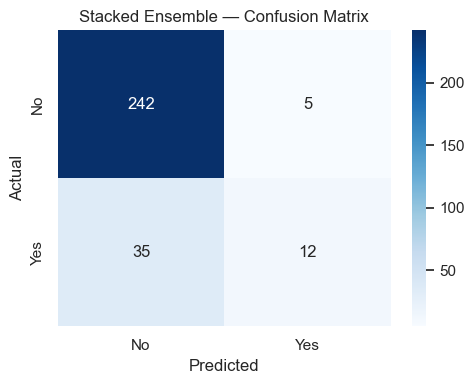

In [14]:
print(classification_report(y_test, (final_meta_prob >= 0.5).astype(int),
                             target_names=["No", "Yes"]))

cm = confusion_matrix(y_test, (final_meta_prob >= 0.5).astype(int))
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No", "Yes"], yticklabels=["No", "Yes"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Stacked Ensemble — Confusion Matrix")
plt.tight_layout()
plt.show()


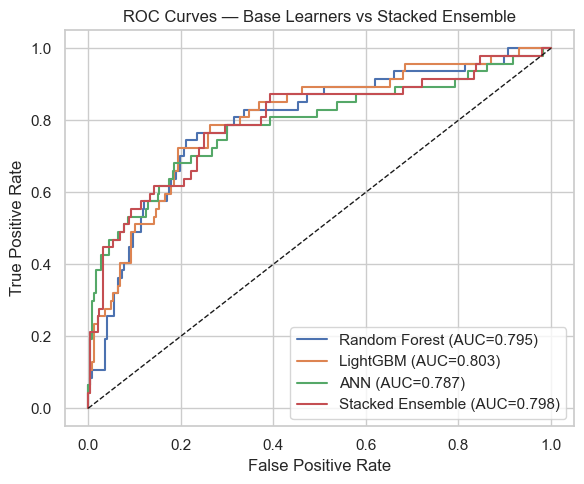

In [15]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, prob in [("Random Forest", test_rf), ("LightGBM", test_lgbm),
                    ("ANN", test_ann), ("Stacked Ensemble", final_meta_prob)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, prob):.3f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Base Learners vs Stacked Ensemble")
ax.legend()
plt.tight_layout()
plt.show()


## 9. Save Artifacts for Deployment

Saved to `../backend/models/` to match the project's repo structure. `preprocess_data.py` has already
saved `artifacts/preprocessor.pkl`, `artifacts/target_encoder.pkl`, and `artifacts/feature_names.pkl` —
those should be copied alongside these into `backend/models/` as well.


In [16]:
MODELS_DIR = "../backend/models"
os.makedirs(MODELS_DIR, exist_ok=True)

joblib.dump(final_rf, os.path.join(MODELS_DIR, "final_rf.pkl"))
joblib.dump(final_lgbm, os.path.join(MODELS_DIR, "final_lgbm.pkl"))
joblib.dump(meta_learner, os.path.join(MODELS_DIR, "meta_learner.pkl"))
final_ann.save(os.path.join(MODELS_DIR, "final_ann.h5"))

with open(os.path.join(MODELS_DIR, "stacking_metrics.json"), "w") as f:
    json.dump(results_df.reset_index().to_dict(orient="records"), f, indent=2)

print("Saved: final_rf.pkl, final_lgbm.pkl, meta_learner.pkl, final_ann.h5, stacking_metrics.json")
print(f"Location: {os.path.abspath(MODELS_DIR)}")


Saved: final_rf.pkl, final_lgbm.pkl, meta_learner.pkl, final_ann.h5, stacking_metrics.json
Location: d:\Employee_Attrition_Prediction_System\backend\models


## 10. Inference Function (reference for `backend/ml/predictor.py`)

At prediction time: transform the raw input with the saved `preprocessor.pkl`, get each base
learner's probability, stack them, and pass through the meta-learner. This mirrors exactly what
`get_oof_predictions`/Section 7 do, minus the fold loop.


In [17]:
def predict_attrition_stacked(raw_input_df, preprocessor, final_rf, final_lgbm, final_ann, meta_learner):
    X = preprocessor.transform(raw_input_df)
    if hasattr(X, "toarray"):
        X = X.toarray()

    p_rf = final_rf.predict_proba(X)[:, 1]
    p_lgbm = final_lgbm.predict_proba(X)[:, 1]
    p_ann = final_ann.predict(X, verbose=0).ravel()

    Z = np.column_stack([p_rf, p_lgbm, p_ann])
    prob = meta_learner.predict_proba(Z)[:, 1]

    return {
        "prediction": ["Yes" if p > 0.5 else "No" for p in prob],
        "probability": prob.round(4).tolist(),
    }
